![fake-news-hero-img](fake-news-hero-img.jpg)

#  Fake News Detection Project

Ce projet consiste à détecter automatiquement les fausses informations (Fake News) à l'aide de techniques de Machine Learning 

Avec l’augmentation des informations en ligne, il devient essentiel de distinguer les vraies informations des fausses.

## Objectif

L’objectif est de construire un modèle capable de classifier une information en :
- Fake News (0)
- True News (1)

#  Analyse Exploratoire (EDA)

In [5]:
!pip install wordcloud


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\MON_PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


##  Importation des bibliothèques

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


![fake-news-hero-img](fake-news-hero-img.jpg)

#  Fake News Detection Project

Ce projet consiste à détecter automatiquement les fausses informations (Fake News) à l'aide de techniques de Machine Learning et de traitement du langage naturel (NLP).

Avec l’augmentation des informations en ligne, il devient essentiel de distinguer les vraies informations des fausses.

## Objectif

L’objectif est de construire un modèle capable de classifier une information en :
- Fake News (0)
- True News (1)

##  1.Chargement des données

In [190]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [191]:
import pandas as pd

df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

In [192]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [193]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [194]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## Ajouter les labels

In [196]:
df_fake["class"] = 0
df_true["class"] = 1

## Suppression des 10 dernières lignes pour les tests manuels

In [198]:

df_fake_manual_testing = df_fake.tail(10)
for i in range(23480,23470,-1):
    df_fake.drop([i], axis = 0, inplace = True)
    
    
df_true_manual_testing = df_true.tail(10)
for i in range(21416,21406,-1):
    df_true.drop([i], axis = 0, inplace = True)

In [199]:
df_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [200]:
df_true_manual_testing.head(10)

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


## 2.Fusion des datasets

In [202]:
df = pd.concat([df_fake, df_true])
df = df.sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)

# Sauvegarde du dataset fusionné
df.to_csv('dataset_final.csv', index=False)

print(f'dataset_final.csv sauvegardé — {len(df):,} lignes, {df.shape[1]} colonnes')
print(f'   Fake (0) : {(df["class"]==0).sum():,}')
print(f'   Real (1) : {(df["class"]==1).sum():,}')


dataset_final.csv sauvegardé — 44,878 lignes, 5 colonnes
   Fake (0) : 23,471
   Real (1) : 21,407


# Aperçu des données

In [204]:
df.head()

,title,text,subject,date,class
0,White House Officials Admit That Trump LIED A...,Donald Trump has been bragging about his inaug...,News,"January 21, 2017",0
1,Egypt says bombs militants responsible for Wes...,CAIRO (Reuters) - Egypt s air force killed a l...,worldnews,"October 31, 2017",1
2,OUTRAGEOUS! Intimidation of Citizens Opposed t...,"A press release by Bernards Township, NJ is pr...",Government News,"Mar 28, 2017",0
3,AS TRUMP’S POPULARITY SOARS ABROAD…Village In ...,President Donald Trump welcomed India s Prime ...,left-news,"Jun 27, 2017",0
4,"Lebanon ex-PM meets French, UK, EU, U.S. diplo...","BEIRUT (Reuters) - Saad al-Hariri, who resigne...",worldnews,"November 9, 2017",1



## 3. Graphique de distribution Fake vs True

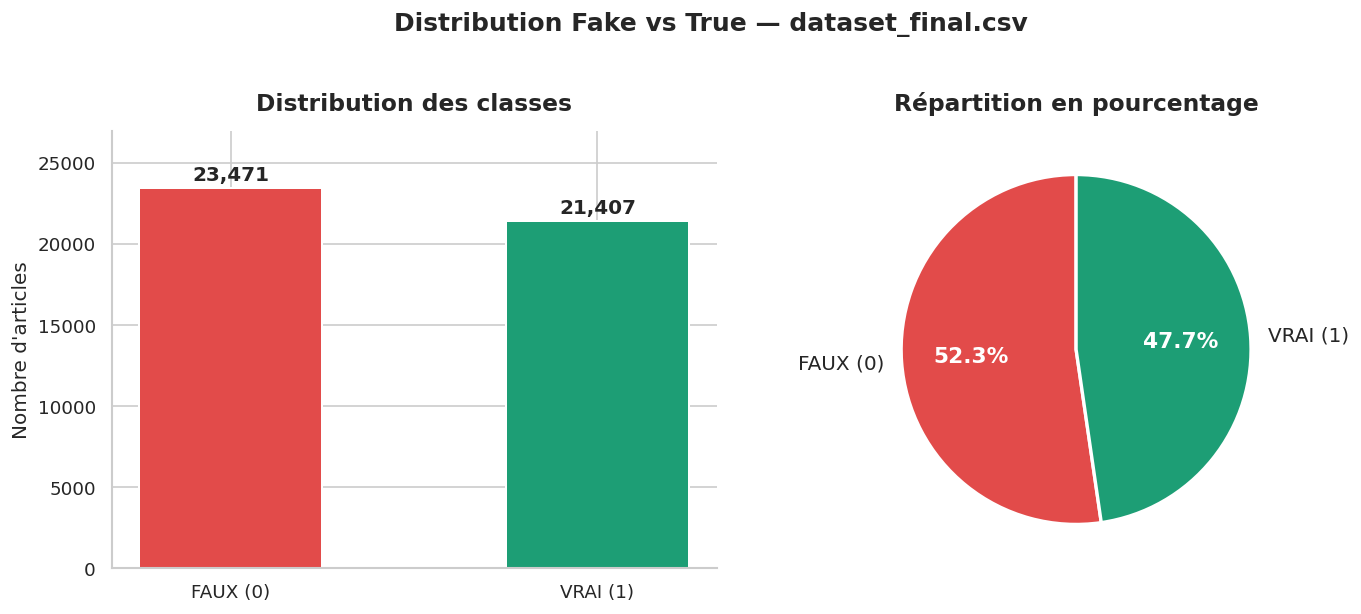

FAUX : 23,471 articles (52.3%)
VRAI : 21,407 articles (47.7%)
 Dataset bien équilibré (ratio < 2:1) → pas besoin de rééchantillonnage


In [206]:
counts = df['class'].value_counts().sort_index()
labels_names = ['FAUX (0)', 'VRAI (1)']
colors = ['#E24B4A', '#1D9E75']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Barres ---
bars = axes[0].bar(labels_names, counts.values, color=colors,
                   width=0.5, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribution des classes', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Nombre d\'articles')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.15)
axes[0].spines[['top','right']].set_visible(False)

# --- Camembert ---
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels_names, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')
axes[1].set_title('Répartition en pourcentage', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Distribution Fake vs True — dataset_final.csv',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution.png', bbox_inches='tight')
plt.show()

print(f'FAUX : {counts[0]:,} articles ({counts[0]/len(df)*100:.1f}%)')
print(f'VRAI : {counts[1]:,} articles ({counts[1]/len(df)*100:.1f}%)')
print(' Dataset bien équilibré (ratio < 2:1) → pas besoin de rééchantillonnage')

---
## 4. WordCloud des mots les plus fréquents

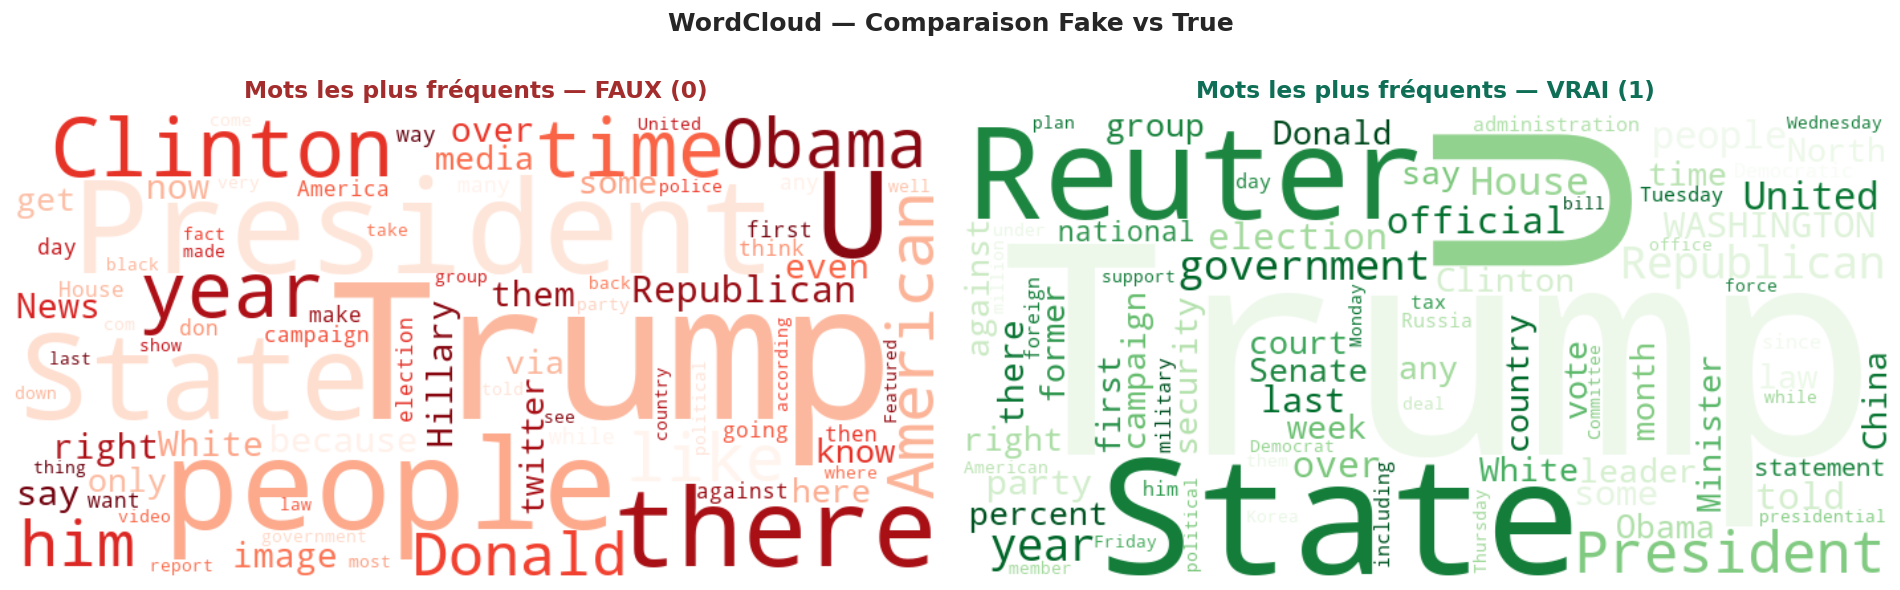

 WordClouds générés


In [208]:

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','are',
    'was','were','be','been','being','have','has','had','do','does','did',
    'will','would','could','should','may','might','this','that','these','those',
    'it','its','as','by','from','with','he','she','they','we','you','i',
    'his','her','their','our','your','my','not','no','so','if','than',
    'about','after','before','between','into','through','during','said',
    'also','more','other','up','out','what','when','who','which','how',
    'one','two','all','new','can','just','s','t','re','ve','ll','d','m'
}

text_fake = ' '.join(df[df['class'] == 0]['text'].astype(str).tolist())
text_true = ' '.join(df[df['class'] == 1]['text'].astype(str).tolist())

wc_fake = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='Reds',
    max_words=80,
    collocations=False
).generate(text_fake)

wc_true = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='Greens',
    max_words=80,
    collocations=False
).generate(text_true)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Mots les plus fréquents — FAUX (0)',
                  fontsize=14, fontweight='bold', color='#A32D2D', pad=10)

axes[1].imshow(wc_true, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Mots les plus fréquents — VRAI (1)',
                  fontsize=14, fontweight='bold', color='#0F6E56', pad=10)

plt.suptitle('WordCloud — Comparaison Fake vs True',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_wordcloud.png', bbox_inches='tight')
plt.show()
print(' WordClouds générés')

---
## 5. Détecter les déséquilibres dans les données

In [210]:
print('═' * 50)
print('RAPPORT DE DÉSÉQUILIBRE DES DONNÉES')
print('═' * 50)

# 1. Déséquilibre de classes
print('\n 1. CLASSES (label)')
vc = df['class'].value_counts()
ratio = vc.max() / vc.min()
print(f'   FAUX : {vc[0]:,} articles')
print(f'   VRAI : {vc[1]:,} articles')
print(f'   Ratio max/min : {ratio:.2f}')
if ratio < 2:
    print('    Équilibré — aucune technique de rééchantillonnage nécessaire')
else:
    print('    Déséquilibre détecté — envisager SMOTE ou class_weight')

# 2. Valeurs manquantes
print('\n 2. VALEURS MANQUANTES')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('    Aucune valeur manquante dans le dataset')
else:
    print(missing[missing > 0])

# 3. Doublons
print('\n 3. DOUBLONS')
dupes = df.duplicated().sum()
print(f'   Lignes dupliquées : {dupes}')
if dupes > 0:
    print('     Faut  supprimer les doublons avant entraînement')
else:
    print('    Aucun doublon détecté')

# 4. Sujets par classe
print('\n 4. RÉPARTITION PAR SUJET')
print(df.groupby(['class', 'subject']).size().reset_index(name='count').to_string(index=False))

print('\n' + '═' * 50)

══════════════════════════════════════════════════
RAPPORT DE DÉSÉQUILIBRE DES DONNÉES
══════════════════════════════════════════════════

 1. CLASSES (label)
   FAUX : 23,471 articles
   VRAI : 21,407 articles
   Ratio max/min : 1.10
    Équilibré — aucune technique de rééchantillonnage nécessaire

 2. VALEURS MANQUANTES
    Aucune valeur manquante dans le dataset

 3. DOUBLONS
   Lignes dupliquées : 208
     Faut  supprimer les doublons avant entraînement

 4. RÉPARTITION PAR SUJET
 class         subject  count
     0 Government News   1570
     0     Middle-east    768
     0            News   9050
     0         US_News    783
     0       left-news   4459
     0        politics   6841
     1    politicsNews  11272
     1       worldnews  10135

══════════════════════════════════════════════════


In [211]:
# Suppression des lignes dupliquées avant l'entraînement
df = df.drop_duplicates()
print(f"Après suppression des doublons : {len(df)} lignes restantes")

Après suppression des doublons : 44670 lignes restantes


---
## 6. Graphique des sujets par classe

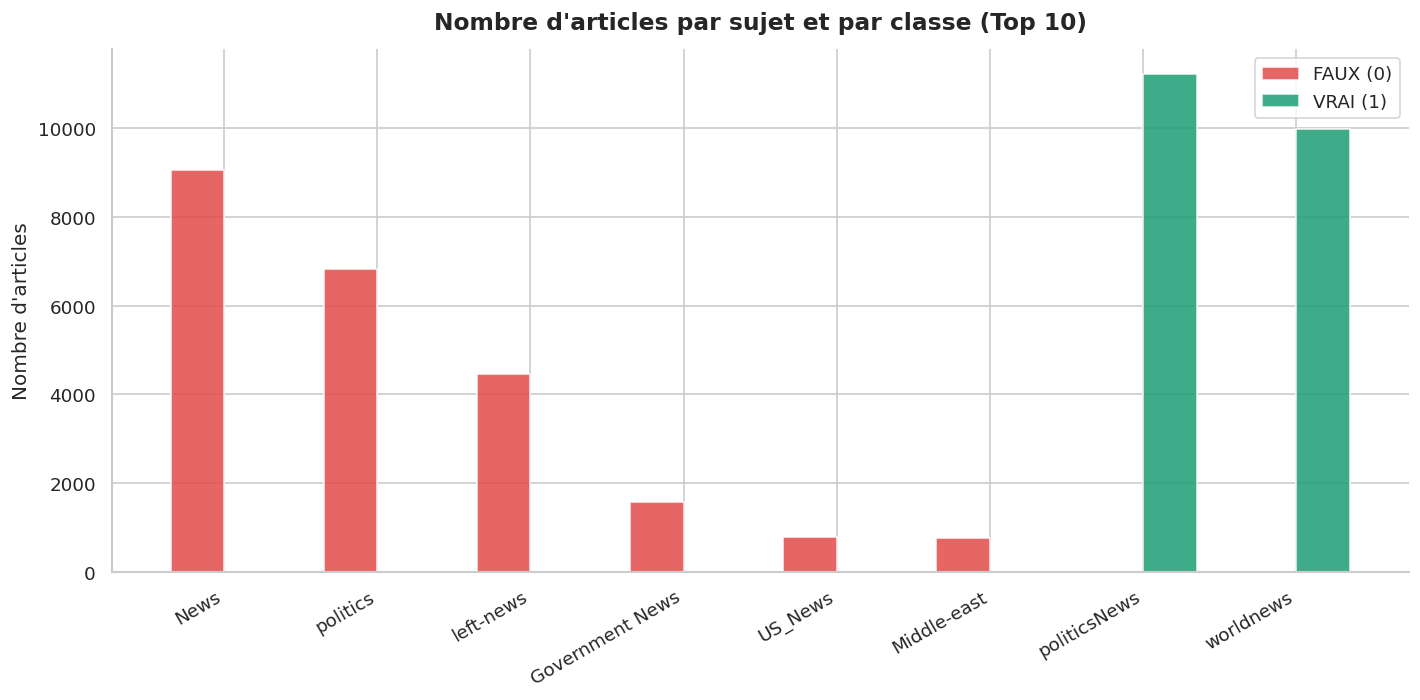

Graphique sujets généré


In [213]:
subject_counts = df.groupby(['subject', 'class']).size().unstack(fill_value=0)
subject_counts = subject_counts.sort_values(by=subject_counts.columns.tolist(), ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(subject_counts))
width = 0.35

if 0 in subject_counts.columns:
    bars1 = ax.bar([i - width/2 for i in x], subject_counts[0], width,
                   label='FAUX (0)', color='#E24B4A', alpha=0.85, edgecolor='white')
if 1 in subject_counts.columns:
    bars2 = ax.bar([i + width/2 for i in x], subject_counts[1], width,
                   label='VRAI (1)', color='#1D9E75', alpha=0.85, edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(subject_counts.index, rotation=30, ha='right', fontsize=11)
ax.set_title('Nombre d\'articles par sujet et par classe (Top 10)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Nombre d\'articles')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_sujets.png', bbox_inches='tight')
plt.show()
print('Graphique sujets généré')

---
## 7. Nettoyage du texte

Cette section effectue le prétraitement des textes avant modélisation :
1. **Suppression des liens URL**
2. **Suppression de la ponctuation & des caractères spéciaux**
3. **Mise en minuscules**
4. **Suppression des stopwords**


In [215]:
import re
import string
import nltk

# Télécharger les stopwords NLTK (une seule fois)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print(' Bibliothèques de nettoyage importées')

 Bibliothèques de nettoyage importées


[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


In [216]:
# Stopwords anglais (NLTK) + quelques ajouts spécifiques au dataset
STOP_WORDS = set(stopwords.words('english')) | {
    'said', 'would', 'could', 'also', 'one', 'two', 'three',
    'us', 'reuters', 'news', 'u', 's'
}

def clean_text(text: str) -> str:
    """Pipeline complet de nettoyage d'un texte."""

    # 1  Supprimer les liens URL  (http/https/www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 2  Enlever la ponctuation & les caractères spéciaux
    # On conserve uniquement les lettres et les espaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 3 Mettre tout en minuscules
    text = text.lower()

    # 4  Supprimer les stopwords
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in STOP_WORDS and len(tok) > 1]

    return ' '.join(tokens)

print(' Fonction clean_text() définie')

 Fonction clean_text() définie


In [217]:
# ── Test rapide sur un exemple ──────────────────────────────────────────────
sample = (
    "Breaking News! Visit https://fakenews.com/article?id=123 "
    "for more info. The U.S. President said: 'This is GREAT!!!' "
    "— @user #trending 2024."
)

cleaned = clean_text(sample)
print('Texte original :')
print(' ', sample)
print()
print('Texte nettoyé  :')
print(' ', cleaned)

Texte original :
  Breaking News! Visit https://fakenews.com/article?id=123 for more info. The U.S. President said: 'This is GREAT!!!' — @user #trending 2024.

Texte nettoyé  :
  breaking visit info president great user trending


## Suppression des colonnes inutiles

In [242]:
df = df.drop(["title", "subject","date"], axis = 1)

In [246]:
df.isnull().sum()

text     0
class    0
dtype: int64

## Mélange aléatoire du dataframe

In [257]:
df.head()

,text,class
0,Former acting Attorney General Sally Yates was...,0
1,SARAJEVO (Reuters) - Islamic State flags are n...,1
2,WASHINGTON (Reuters) - The Republican chairman...,1
3,DONALD TRUMP and KANYE WEST Greet Reporters Af...,0
4,Kirsten Powers USA TodayOver the past 18 month...,0


### Définition des variables dépendantes et indépendantes

In [261]:
x = df["text"]
y = df["class"]

## 8.Séparation de l'entraînement et des tests


In [264]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)


## 9.Vectorisation avec TF-IDF

In [266]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [289]:
print(xv_train[0])

  (0, 31291)	0.08000132980896918
  (0, 98411)	0.23482927460256367
  (0, 50497)	0.12802995812603368
  (0, 93385)	0.04855989414355715
  (0, 96955)	0.12256940662269475
  (0, 44639)	0.044781850892964915
  (0, 87057)	0.032548810600076854
  (0, 48463)	0.03674084415092823
  (0, 74328)	0.04481613444940829
  (0, 19664)	0.08181822875396809
  (0, 105362)	0.026537077083855318
  (0, 105749)	0.17595119387901664
  (0, 57025)	0.0688982878051512
  (0, 96993)	0.0343890647225316
  (0, 10238)	0.08485588696301237
  (0, 104578)	0.06103280553886507
  (0, 14981)	0.048965281194143354
  (0, 15909)	0.07408625098509039
  (0, 11932)	0.05664896436037621
  (0, 27777)	0.02853667812038001
  (0, 70111)	0.11258872795721366
  (0, 30118)	0.05903944544093733
  (0, 41360)	0.03576249462213108
  (0, 49084)	0.08637031162046101
  (0, 10424)	0.15898810814178937
  :	:
  (0, 57062)	0.05922565996627093
  (0, 23931)	0.037889587460474314
  (0, 38425)	0.05491380246273353
  (0, 10101)	0.02709857153648223
  (0, 48863)	0.0502677248353528

In [291]:
print(xv_train[0].toarray())

[[0. 0. 0. ... 0. 0. 0.]]


In [293]:
print(xv_train.shape)

(33502, 108241)
